# Generación Sintetica de datos

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms 
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

Se generan 1000 datos dentro del rango[0,10] y 1000 dentro del rango [-4,0]U[10,14] de la siguiente funcion

$ y = x*sinx + 0.3*x*e_1 +0.3*e_2 $ 

donde $e_1, e_2 ~ N(0,1)$


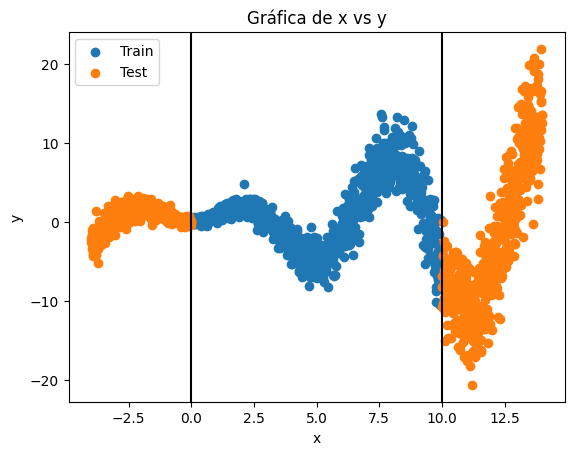

In [2]:
# Fijar semilla
np.random.seed(42)

# Número de observaciones
n = 1000
step = 10 / 1000  # 0.01

# Generar x con paso fijo

x = np.linspace(0, 10, n, endpoint=False)
x1 = np.linspace(-4,0,n//2,endpoint=False)
x2 = np.linspace(10,14,n//2,endpoint=False)

# Generar errores
e1 = np.random.normal(0, 1, n)
e2 = np.random.normal(0, 1, n)
e3 = np.random.normal(0, 1, n//2)
e4 = np.random.normal(0, 1, n//2)
e5 = np.random.normal(0, 1, n//2)
e6 = np.random.normal(0, 1, n//2)

# Generar y
y = x * np.sin(x) + 0.3 * x * e1 + 0.3 * e2

y1 = x1 * np.sin(x1) + 0.3 * x1 * e3 + 0.3 * e4

y2 = x2 * np.sin(x2) + 0.3 * x2 * e5+ 0.3 * e6

# Crear DataFrame
x_train = pd.DataFrame({
    "x": x,
    "y": y
})

x1_test = pd.DataFrame({
    "x": x1,
    "y": y1
})

x2_test = pd.DataFrame({
    "x": x2,
    "y": y2
})   

x_test = pd.concat([x1_test, x2_test], ignore_index=True)


plt.figure()

plt.scatter(x_train["x"], x_train["y"], label="Train")
plt.scatter(x_test["x"], x_test["y"], label="Test")
plt.axvline(x=0, color='black')
plt.axvline(x=10, color='black')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gráfica de x vs y")
plt.legend()

plt.show()



# ME network


In [ ]:
'''
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#hiperparametros
hidden_size = 256 #num neuronas en la capa oculta
num_epochs = 20000
batch_size = 32
learning_rate = 0.001 # tasa de aprendizaje

#pasar datos a tensores
X = torch.tensor(x_train["x"].values, dtype=torch.float32).view(-1,1)
Y = torch.tensor(x_train["y"].values, dtype=torch.float32).view(-1,1)


dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

class MEnetwork(nn.Module):
    def __init__(self, hidden_size):
        super(MEnetwork, self).__init__()
        self.l1 = nn.Linear(1, hidden_size)
        self.tanh1 = nn.Tanh()
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.tanh2 = nn.Tanh()
        self.l3 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out = self.l1(x)
        out = self.tanh1(out)
        out = self.l2(out)
        out = self.tanh2(out)
        out = self.l3(out)
        return out
    


model = MEnetwork(hidden_size)

model.to(device)

criterion = nn.MSELoss() #al simplificar la ecuacion, se estaria minimizando MSE
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):

    for xb, yb in loader:
        
        xb = xb.to(device)
        yb = yb.to(device)

        # Forward
        y_pred = model(xb)
        loss = criterion(y_pred, yb)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    if (epoch+1) % 500 == 0:
        print(f"  Epoch [{epoch+1}/{num_epochs}] - Loss: {loss.item():.4f}")

model.eval()

with torch.no_grad():
    y_pred = model(X.to(device)).cpu().numpy()

y_real = Y.numpy()
x_vals = X.numpy()

exportmodel = {
    "model_state":model.state_dict()
}

torch.save(exportmodel, "modelMEnetwork.pth")

pd.DataFrame({"x": X.cpu().numpy().flatten(),"y_real": Y.cpu().numpy().flatten(),
              "y_pred": model(X.to(device)).detach().cpu().numpy().flatten(),
              "residuo": (Y - model(X.to(device)).detach().cpu()).numpy().flatten(),
              "residuo_cuadrado": ((Y - model(X.to(device)).detach().cpu())**2).numpy().flatten()}).to_csv("datos_modelo_train.csv", index=False)

'''

  Epoch [500/20000] - Loss: 2.9525
  Epoch [1000/20000] - Loss: 1.6076
  Epoch [1500/20000] - Loss: 0.8344
  Epoch [2000/20000] - Loss: 3.6828
  Epoch [2500/20000] - Loss: 3.0665
  Epoch [3000/20000] - Loss: 1.5440
  Epoch [3500/20000] - Loss: 4.0026
  Epoch [4000/20000] - Loss: 5.6573
  Epoch [4500/20000] - Loss: 1.3416
  Epoch [5000/20000] - Loss: 2.3299
  Epoch [5500/20000] - Loss: 2.5140
  Epoch [6000/20000] - Loss: 2.5082
  Epoch [6500/20000] - Loss: 3.4884
  Epoch [7000/20000] - Loss: 2.3588
  Epoch [7500/20000] - Loss: 4.8490
  Epoch [8000/20000] - Loss: 4.1560
  Epoch [8500/20000] - Loss: 1.3906
  Epoch [9000/20000] - Loss: 1.9703
  Epoch [9500/20000] - Loss: 1.3915
  Epoch [10000/20000] - Loss: 0.8962
  Epoch [10500/20000] - Loss: 2.1476
  Epoch [11000/20000] - Loss: 0.7941
  Epoch [11500/20000] - Loss: 2.2513
  Epoch [12000/20000] - Loss: 0.4317
  Epoch [12500/20000] - Loss: 5.3651
  Epoch [13000/20000] - Loss: 2.1103
  Epoch [13500/20000] - Loss: 5.3682
  Epoch [14000/20000]

## estimación de los datos

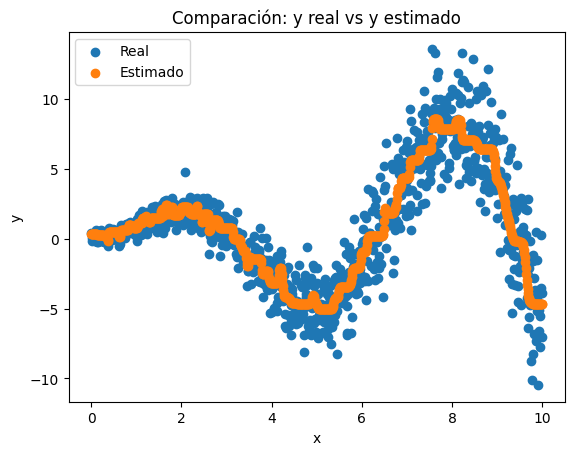

In [8]:


df = pd.read_csv("datos_modelo_train.csv")

x_vals, y_real, y_pred = df["x"].values, df["y_real"].values, df["y_pred"].values


plt.figure()

plt.scatter(x_vals, y_real, label="Real")
plt.scatter(x_vals, y_pred, label="Estimado")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparación: y real vs y estimado")
plt.legend()

plt.show()


## testeo de MEnetwork

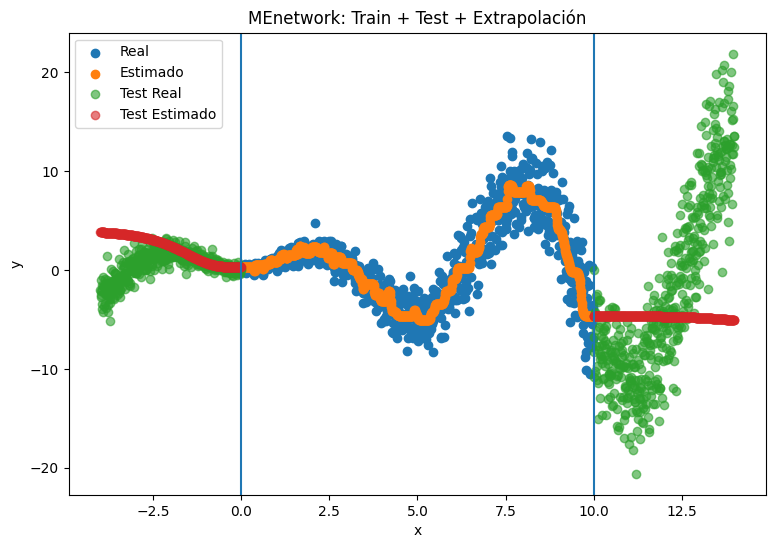

===== TRAIN =====
MSE Train:  2.701947
RMSE Train: 1.643760

===== TEST =====
MSE Test:  51.088014
RMSE Test: 7.147588

 Archivo 'datos_modelos_test.csv' exportado exitosamente


In [9]:
# ---------------------------------------------------------
# Reconstruir arquitectura MEnetwork
# ---------------------------------------------------------

df = pd.read_csv("datos_modelo_train.csv")

x_vals, y_real, y_pred = df["x"].values, df["y_real"].values, df["y_pred"].values

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

hidden_size = 256

class MEnetwork(nn.Module):
    def __init__(self, hidden_size):
        super(MEnetwork, self).__init__()
        self.l1 = nn.Linear(1, hidden_size)
        self.tanh1 = nn.Tanh()
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.tanh2 = nn.Tanh()
        self.l3 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out = self.l1(x)
        out = self.tanh1(out)
        out = self.l2(out)
        out = self.tanh2(out)
        out = self.l3(out)
        return out



# ---------------------------------------------------------
# Cargar modelo entrenado
# ---------------------------------------------------------

checkpoint = torch.load("modelMEnetwork.pth", map_location=device)

model = MEnetwork(hidden_size)
model.load_state_dict(checkpoint["model_state"])
model.to(device)
model.eval()

# ---------------------------------------------------------
# Convertir test a tensor y predecir
# ---------------------------------------------------------

X_test_tensor = torch.tensor(
    x_test["x"].values,
    dtype=torch.float32
).view(-1,1).to(device)

with torch.no_grad():
    y_test_pred_tensor = model(X_test_tensor)

y_test_pred = y_test_pred_tensor.cpu().numpy().flatten()

# ---------------------------------------------------------
# Extraer valores reales
# ---------------------------------------------------------

x_test_vals = x_test["x"].values
y_test_real = x_test["y"].values

# ---------------------------------------------------------
#  Graficar resultados
# ---------------------------------------------------------

plt.figure(figsize=(9,6))

plt.scatter(x_vals, y_real, label="Real")
plt.scatter(x_vals, y_pred, label="Estimado")

# Test real
plt.scatter(x_test_vals, y_test_real, label="Test Real", alpha=0.6)

# Test estimado
plt.scatter(x_test_vals, y_test_pred, label="Test Estimado", alpha=0.6)

plt.axvline(x=0)
plt.axvline(x=10)

plt.xlabel("x")
plt.ylabel("y")
plt.title("MEnetwork: Train + Test + Extrapolación")
plt.legend()

plt.show()

# =========================================================
# MÉTRICAS TRAIN + TEST
# =========================================================

import numpy as np

# -------------------------
# TRAIN (desde CSV)
# -------------------------

mse_train = np.mean((y_real - y_pred)**2)
rmse_train = np.sqrt(mse_train)

print("===== TRAIN =====")
print(f"MSE Train:  {mse_train:.6f}")
print(f"RMSE Train: {rmse_train:.6f}")

# -------------------------
# TEST (fuera del rango)
# -------------------------

mse_test = np.mean((y_test_real - y_test_pred)**2)
rmse_test = np.sqrt(mse_test)

print("\n===== TEST =====")
print(f"MSE Test:  {mse_test:.6f}")
print(f"RMSE Test: {rmse_test:.6f}")

# ---------------------------------------------------------
# Exportar datos de test a CSV
# ---------------------------------------------------------

pd.DataFrame({
    "x": x_test_vals,
    "y_real": y_test_real,
    "y_pred": y_test_pred,
    "residuo": y_test_real - y_test_pred,
    "residuo_cuadrado": (y_test_real - y_test_pred)**2
}).to_csv("datos_modelos_test.csv", index=False)

print("\n Archivo 'datos_modelos_test.csv' exportado exitosamente")


# Variance Network

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ==============================
# 1️⃣ Cargar datos desde CSV
# ==============================

df = pd.read_csv("datos_modelo_train.csv")

R_input = torch.tensor(df["residuo_cuadrado"].values, dtype=torch.float32).view(-1,1)
R_target = R_input.clone()

dataset_var = TensorDataset(R_input, R_target)
loader_var = DataLoader(dataset_var, batch_size=32, shuffle=True)

#---hiperparámetros
hidden_size = 256 #num neuronas en la capa oculta
num_epochs = 5000
batch_size = 32
learning_rate = 0.001 # tasa de aprendizaje


class VENetwork(nn.Module):
    def __init__(self, hidden_size):
        super(VENetwork, self).__init__()
        self.l1 = nn.Linear(1, hidden_size)
        self.tanh1 = nn.Tanh()
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.tanh2 = nn.Tanh()
        self.l3 = nn.Linear(hidden_size, 5)
        self.l_alpha  = nn.Linear(5, 1)
        self.l_lambda = nn.Linear(5, 1)

    def forward(self, x):
        h = self.tanh1(self.l1(x))
        h = self.tanh2(self.l2(h))
        h = self.tanh2(self.l3(h))

        alpha = torch.abs(self.l_alpha(h)) + 1e-3
        lam   = torch.abs(self.l_lambda(h)) + 1e-3

        return alpha, lam
    

def gamma_nll_loss(r, alpha, lam):

    loss = (
        alpha *( torch.log(lam)-torch.lgamma(alpha))) - ((alpha - 1) * torch.log(r + 1e-8))+ (lam/r)

    return loss.sum()


model_var = VENetwork(hidden_size).to(device)
optimizer_var = torch.optim.Adam(model_var.parameters(), lr=learning_rate)

loss_history_var = []

print(" Entrenando VENetwork...")
for epoch in range(num_epochs):

    for rb_input, rb_target in loader_var:

        rb_input = rb_input.to(device)
        rb_target = rb_target.to(device)

        alpha, lam = model_var(rb_input)

        loss = gamma_nll_loss(rb_target, alpha, lam)

        optimizer_var.zero_grad()
        loss.backward()
        optimizer_var.step()

    loss_history_var.append(loss.item())

    if (epoch+1) % 500 == 0:
        print(f"  Epoch [{epoch+1}/{num_epochs}] - Loss: {loss.item():.4f}")


model_var.eval()

print("\n Entrenamiento completado")

# ========================================================
# Obtener alpha y lambda para TRAIN
# ========================================================


with torch.no_grad():
    alpha_pred, lambda_pred = model_var(R_input.to(device))
    alpha_pred = alpha_pred.cpu().numpy().flatten()
    lambda_pred = lambda_pred.cpu().numpy().flatten()


print(f"  Alpha  - Min: {alpha_pred.min():.4f}, Max: {alpha_pred.max():.4f}, Media: {alpha_pred.mean():.4f}")
print(f"  Lambda - Min: {lambda_pred.min():.4f}, Max: {lambda_pred.max():.4f}, Media: {lambda_pred.mean():.4f}")
print(f"  Primeros 5 valores de Alpha:  {alpha_pred[:5]}")
print(f"  Primeros 5 valores de Lambda: {lambda_pred[:5]}")

# Cargar el CSV de TRAIN y agregar las nuevas columnas
df_train = pd.read_csv("datos_modelo_train.csv")
df_train["alpha"] = alpha_pred
df_train["lambda"] = lambda_pred

# Guardar el CSV de TRAIN actualizado
df_train.to_csv("datos_modelo_train.csv", index=False)

# ========================================================
# Obtener alpha y lambda para TEST
# ========================================================

# Cargar los residuos cuadrados del test
df_test = pd.read_csv("datos_modelos_test.csv")
R_test_input = torch.tensor(df_test["residuo_cuadrado"].values, dtype=torch.float32).view(-1,1)

with torch.no_grad():
    alpha_pred_test, lambda_pred_test = model_var(R_test_input.to(device))
    alpha_pred_test = alpha_pred_test.cpu().numpy().flatten()
    lambda_pred_test = lambda_pred_test.cpu().numpy().flatten()

# Agregar las nuevas columnas al CSV de TEST
df_test["alpha"] = alpha_pred_test
df_test["lambda"] = lambda_pred_test

# Guardar el CSV de TEST actualizado
df_test.to_csv("datos_modelos_test.csv", index=False)
print("\n✓ CSV 'datos_modelos_test.csv' actualizado")

# ========================================================
# Guardar el modelo VENetwork
# ========================================================

exportmodel = {
    "model_state": model_var.state_dict(),
    "optim_state": optimizer_var.state_dict()
}

torch.save(exportmodel, "modelVEnetwork.pth")

print("\n Modelo 'modelVEnetwork.pth' guardado")

print(" PROCESO COMPLETADO EXITOSAMENTE")



 Entrenando VENetwork...
  Epoch [500/5000] - Loss: -418170.8125
  Epoch [1000/5000] - Loss: -1649890.2500
  Epoch [1500/5000] - Loss: -3764726.2500
  Epoch [2000/5000] - Loss: -6813428.0000
  Epoch [2500/5000] - Loss: -10825263.0000
  Epoch [3000/5000] - Loss: -15825554.0000
  Epoch [3500/5000] - Loss: -21831882.0000
  Epoch [4000/5000] - Loss: -28883098.0000
  Epoch [4500/5000] - Loss: -36978740.0000
  Epoch [5000/5000] - Loss: -46148224.0000

 Entrenamiento completado
  Alpha  - Min: 988.8851, Max: 988.8851, Media: 988.8849
  Lambda - Min: 0.0035, Max: 0.0035, Media: 0.0035
  Primeros 5 valores de Alpha:  [988.8851 988.8851 988.8851 988.8851 988.8851]
  Primeros 5 valores de Lambda: [0.00348337 0.00348337 0.00348337 0.00348337 0.00348337]

✓ CSV 'datos_modelos_test.csv' actualizado

 Modelo 'modelVEnetwork.pth' guardado
 PROCESO COMPLETADO EXITOSAMENTE


calcular varianzas

Visualizacion train test con intervalos de confianza

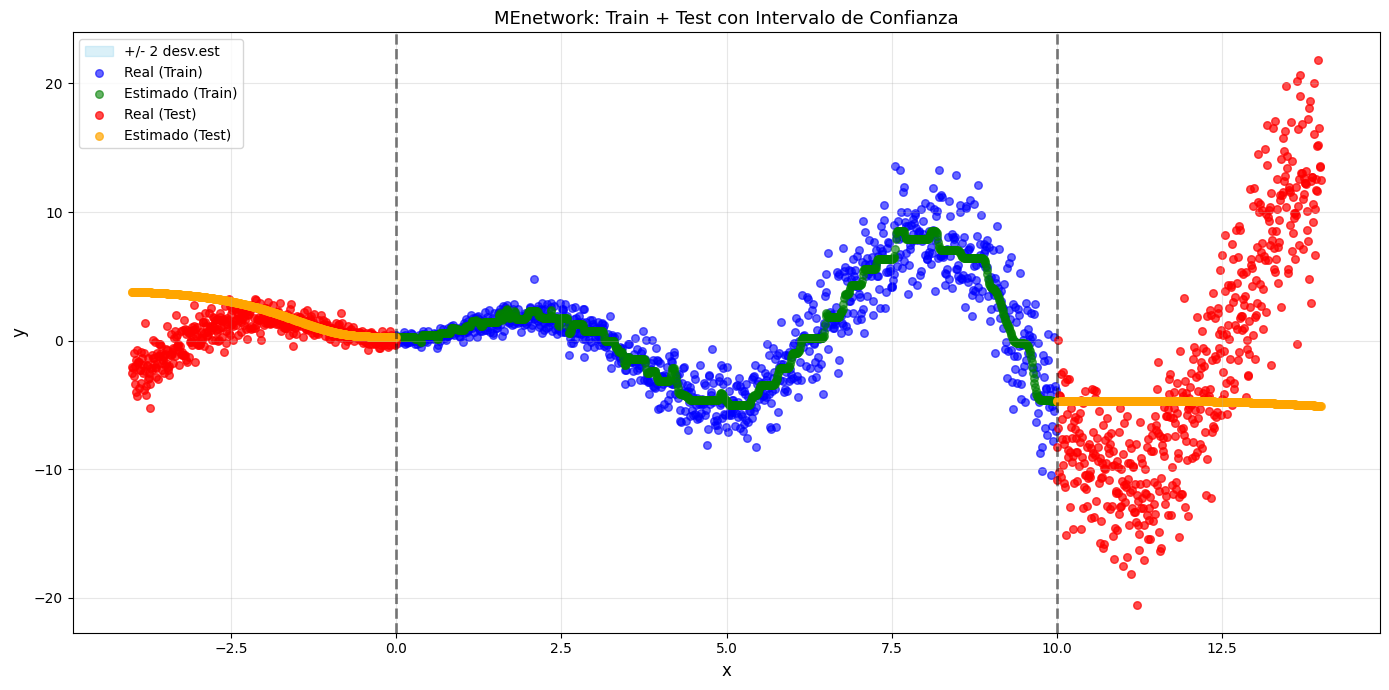

In [11]:
# Cargar datos de train y test
df_train = pd.read_csv("datos_modelo_train.csv")
df_test = pd.read_csv("datos_modelos_test.csv")

# Reconstruir MEnetwork y VEnetwork
class MEnetwork(nn.Module):
    def __init__(self, hidden_size):
        super(MEnetwork, self).__init__()
        self.l1 = nn.Linear(1, hidden_size)
        self.tanh = nn.Tanh()
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.tanh = nn.Tanh()
        self.l3 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out = self.l1(x)
        out = self.tanh(out)
        out = self.l2(out)
        out = self.tanh(out)
        out = self.l3(out)
        return out

class VENetwork(nn.Module):
    def __init__(self, hidden_size):
        super(VENetwork, self).__init__()

        self.l1 = nn.Linear(1, hidden_size)
        self.act1 = nn.Tanh()
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.act2 = nn.Tanh()
        self.l3 = nn.Linear(hidden_size, 5)
        self.act3 = nn.Tanh()

        self.l_alpha = nn.Linear(5, 1)
        self.l_lambda = nn.Linear(5, 1)

        self.softplus = nn.Softplus()

    def forward(self, r):

        h = self.act1(self.l1(r))
        h = self.act2(self.l2(h))
        h = self.act3(self.l3(h))

        alpha = self.softplus(self.l_alpha(h)) + 1e-6
        lam   = self.softplus(self.l_lambda(h)) + 1e-6

        return alpha, lam

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hidden_size = 256

# Cargar modelos
checkpoint_me = torch.load("modelMEnetwork.pth", map_location=device)
model_me = MEnetwork(hidden_size)
model_me.load_state_dict(checkpoint_me["model_state"])
model_me.to(device)
model_me.eval()

checkpoint_ve = torch.load("modelVEnetwork.pth", map_location=device)
model_ve = VENetwork(hidden_size)
model_ve.load_state_dict(checkpoint_ve["model_state"])
model_ve.to(device)
model_ve.eval()

# Combinar datos de TRAIN y TEST en un unico dataframe
df_combined = pd.concat([df_train, df_test], ignore_index=True)

# Ordenar por x
df_combined = df_combined.sort_values(by='x').reset_index(drop=True)

# Extraer valores combinados
x_combined = df_combined["x"].values
y_combined_pred = df_combined["y_pred"].values
residuos_combined = df_combined["residuo_cuadrado"].values

# Calcular desviaciones estandar para la franja unida
R_combined_tensor = torch.tensor(residuos_combined, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    alpha_combined, lambda_combined = model_ve(R_combined_tensor.to(device))
    alpha_combined = alpha_combined.cpu().numpy().flatten()
    lambda_combined = lambda_combined.cpu().numpy().flatten()


desvest_combined = np.sqrt(alpha_combined/lambda_combined)

# Extraer valores de train y test por separado para graficar puntos
x_train_vals = df_train["x"].values
y_train_real = df_train["y_real"].values
y_train_pred = df_train["y_pred"].values

x_test_vals = df_test["x"].values
y_test_real = df_test["y_real"].values
y_test_pred = df_test["y_pred"].values

# Crear figura
fig, ax = plt.subplots(figsize=(14, 7))

# Graficar la unica franja de intervalo de confianza continua (-4 a 14)
ax.fill_between(x_combined,
                 y_combined_pred - 2 * desvest_combined,
                 y_combined_pred + 2 * desvest_combined,
                 alpha=0.3, color='skyblue', label='+/- 2 desv.est')

# Graficar datos reales de train
ax.scatter(x_train_vals, y_train_real, 
          label='Real (Train)', alpha=0.6, s=30, color='blue')

# Graficar estimados de train
ax.scatter(x_train_vals, y_train_pred, 
          label='Estimado (Train)', alpha=0.6, s=30, color='green')

# Graficar datos reales de test
ax.scatter(x_test_vals, y_test_real, 
          label='Real (Test)', alpha=0.7, s=30, color='red')

# Graficar estimados de test
ax.scatter(x_test_vals, y_test_pred, 
          label='Estimado (Test)', alpha=0.7, s=30, color='orange')

# Lineas verticales delimitando regiones
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=2)
ax.axvline(x=10, color='black', linestyle='--', alpha=0.5, linewidth=2)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('MEnetwork: Train + Test con Intervalo de Confianza', fontsize=13)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
